In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [2]:
np.random.seed(42)

n = 1000

data = pd.DataFrame({
    "Age": np.random.randint(18, 70, n),
    "MonthlyCharges": np.random.uniform(20, 120, n).round(2),
    "Tenure": np.random.randint(1, 73, n),
    "SupportCalls": np.random.randint(0, 10, n),
    "Contract": np.random.choice(
        ["Month-to-month", "One year", "Two year"], n
    )
})

probability = (
    0.25
    + 0.25 * (data["Contract"] == "Month-to-month")
    + 0.15 * (data["SupportCalls"] > 5)
    - 0.15 * (data["Tenure"] > 36)
)

data["Churn"] = np.where(
    np.random.random(n) < probability,
    "Yes",
    "No"
)

data.head()

,Age,MonthlyCharges,Tenure,SupportCalls,Contract,Churn
0,56,73.26,5,2,Month-to-month,No
1,69,44.25,65,5,Month-to-month,Yes
2,46,46.92,30,9,One year,No
3,32,57.73,21,9,Two year,No
4,60,22.01,70,4,Month-to-month,No


In [3]:
print(data.shape)
print(data.info())

print("\nMissing values:")
print(data.isnull().sum())

print("\nStatistics:")
print(data.describe())

print("\nChurn distribution:")
print(data["Churn"].value_counts())

(1000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             1000 non-null   int64  
 1   MonthlyCharges  1000 non-null   float64
 2   Tenure          1000 non-null   int64  
 3   SupportCalls    1000 non-null   int64  
 4   Contract        1000 non-null   object 
 5   Churn           1000 non-null   object 
dtypes: float64(1), int64(3), object(2)
memory usage: 47.0+ KB
None

Missing values:
Age               0
MonthlyCharges    0
Tenure            0
SupportCalls      0
Contract          0
Churn             0
dtype: int64

Statistics:
              Age  MonthlyCharges       Tenure  SupportCalls
count  1000.00000     1000.000000  1000.000000   1000.000000
mean     43.81900       69.819480    35.958000      4.480000
std      14.99103       28.972582    20.533969      2.908274
min      18.00000       20.460000     1.000000    

In [4]:
data = pd.get_dummies(
    data,
    columns=["Contract"],
    drop_first=True
)

data["Churn"] = data["Churn"].map({
    "No": 0,
    "Yes": 1
})

data.head()

,Age,MonthlyCharges,Tenure,SupportCalls,Churn,Contract_One year,Contract_Two year
0,56,73.26,5,2,0,False,False
1,69,44.25,65,5,1,False,False
2,46,46.92,30,9,0,True,False
3,32,57.73,21,9,0,False,True
4,60,22.01,70,4,0,False,False


In [5]:
X = data.drop("Churn", axis=1)
y = data["Churn"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (800, 6)
Testing: (200, 6)


In [7]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [8]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

Accuracy: 67.0 %

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.87      0.78       137
           1       0.45      0.24      0.31        63

    accuracy                           0.67       200
   macro avg       0.58      0.55      0.55       200
weighted avg       0.63      0.67      0.63       200


Confusion Matrix:
[[119  18]
 [ 48  15]]


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      round(accuracy_score(y_test, rf_predictions) * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

Random Forest Accuracy: 61.5 %

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.78      0.74       137
           1       0.35      0.25      0.29        63

    accuracy                           0.61       200
   macro avg       0.52      0.52      0.51       200
weighted avg       0.59      0.61      0.60       200


Confusion Matrix:
[[107  30]
 [ 47  16]]


In [10]:
print("Class Distribution:")
print(y.value_counts())

print("\nPercentage Distribution:")
print(y.value_counts(normalize=True) * 100)

Class Distribution:
Churn
0    684
1    316
Name: count, dtype: int64

Percentage Distribution:
Churn
0    68.4
1    31.6
Name: proportion, dtype: float64


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

balanced_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

balanced_rf.fit(X_train, y_train)

balanced_predictions = balanced_rf.predict(X_test)

print("Balanced Random Forest Accuracy:",
      round(accuracy_score(y_test, balanced_predictions) * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, balanced_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, balanced_predictions))

Balanced Random Forest Accuracy: 62.5 %

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.81      0.75       137
           1       0.35      0.22      0.27        63

    accuracy                           0.62       200
   macro avg       0.52      0.52      0.51       200
weighted avg       0.59      0.62      0.60       200


Confusion Matrix:
[[111  26]
 [ 49  14]]


In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Churn
0    547
1    253
Name: count, dtype: int64

After SMOTE:
Churn
0    547
1    547
Name: count, dtype: int64


In [13]:
smote_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

smote_rf.fit(X_train_smote, y_train_smote)

smote_predictions = smote_rf.predict(X_test)

print(
    "SMOTE Random Forest Accuracy:",
    round(accuracy_score(y_test, smote_predictions) * 100, 2),
    "%"
)

print("\nClassification Report:")
print(classification_report(y_test, smote_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, smote_predictions))

SMOTE Random Forest Accuracy: 50.5 %

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.55      0.61       137
           1       0.29      0.40      0.34        63

    accuracy                           0.51       200
   macro avg       0.48      0.48      0.47       200
weighted avg       0.55      0.51      0.52       200


Confusion Matrix:
[[76 61]
 [38 25]]


In [14]:
from sklearn.linear_model import LogisticRegression

smote_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_lr.fit(X_train_smote, y_train_smote)

smote_lr_predictions = smote_lr.predict(X_test)

print(
    "SMOTE Logistic Regression Accuracy:",
    round(accuracy_score(y_test, smote_lr_predictions) * 100, 2),
    "%"
)

print("\nClassification Report:")
print(classification_report(y_test, smote_lr_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, smote_lr_predictions))

SMOTE Logistic Regression Accuracy: 64.0 %

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.59      0.69       137
           1       0.46      0.75      0.57        63

    accuracy                           0.64       200
   macro avg       0.65      0.67      0.63       200
weighted avg       0.72      0.64      0.65       200


Confusion Matrix:
[[81 56]
 [16 47]]


ROC-AUC Score: 0.713


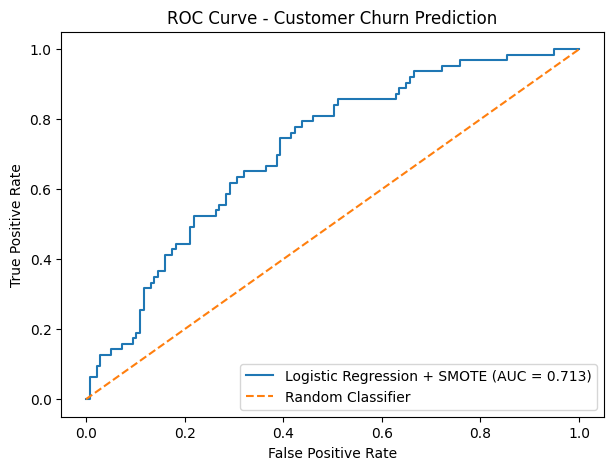

In [15]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Probability of customer belonging to churn class (1)
y_prob = smote_lr.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc_score, 3))

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression + SMOTE (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], "--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")
plt.legend()
plt.show()

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_test = [0.30, 0.40, 0.50, 0.60, 0.70]

print("Threshold | Precision | Recall | F1 Score")
print("------------------------------------------")

for threshold in thresholds_to_test:

    threshold_predictions = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, threshold_predictions)
    recall = recall_score(y_test, threshold_predictions)
    f1 = f1_score(y_test, threshold_predictions)

    print(
        f"{threshold:.2f}      | "
        f"{precision:.2f}      | "
        f"{recall:.2f}   | "
        f"{f1:.2f}"
    )

Threshold | Precision | Recall | F1 Score
------------------------------------------
0.30      | 0.32      | 1.00   | 0.48
0.40      | 0.34      | 0.98   | 0.51
0.50      | 0.46      | 0.75   | 0.57
0.60      | 0.43      | 0.16   | 0.23
0.70      | 0.00      | 0.00   | 0.00


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Top Features Influencing Customer Churn:
             Feature  Coefficient  Importance
4  Contract_One year    -0.236831    0.236831
5  Contract_Two year    -0.211389    0.211389
3       SupportCalls     0.070223    0.070223
2             Tenure    -0.009993    0.009993
0                Age     0.002061    0.002061
1     MonthlyCharges     0.000214    0.000214


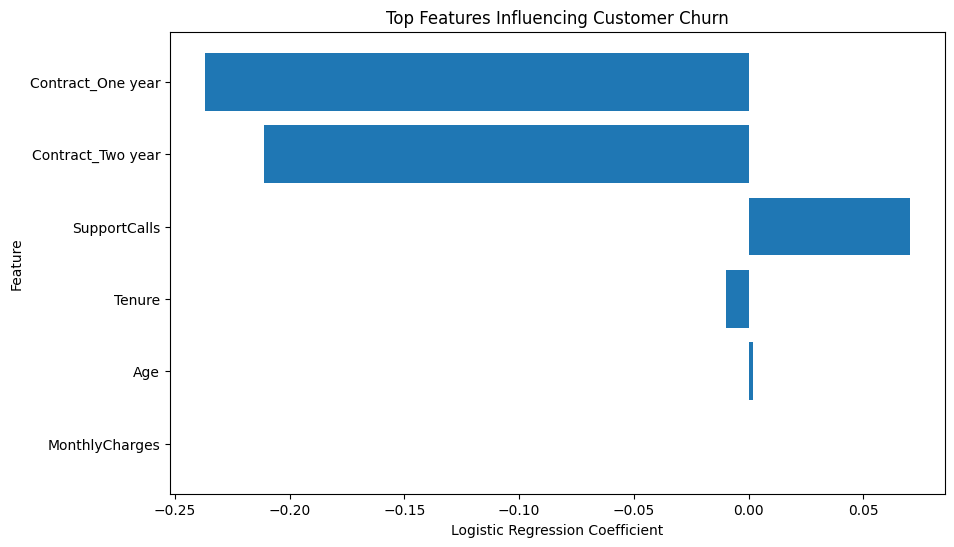

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": smote_lr.coef_[0]
})

feature_importance["Importance"] = abs(feature_importance["Coefficient"])

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top Features Influencing Customer Churn:")
print(feature_importance.head(10))

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Influencing Customer Churn")
plt.gca().invert_yaxis()
plt.show()

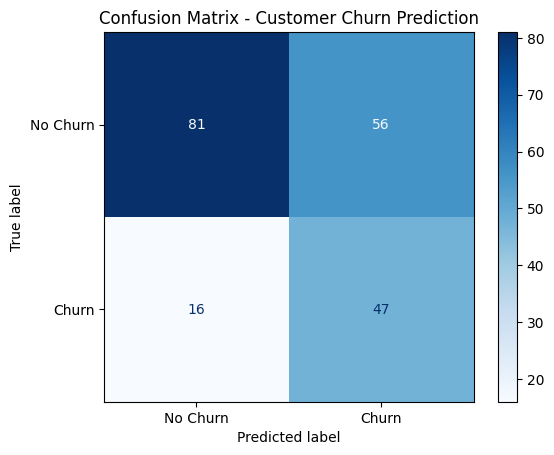

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

final_predictions = (y_prob >= 0.50).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions,
    display_labels=["No Churn", "Churn"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Customer Churn Prediction")
plt.show()

## Final Model Summary

The final model selected for this project is Logistic Regression with SMOTE.

### Model Performance
- Accuracy: 64%
- ROC-AUC: 0.713
- Churn Recall: 75%
- Churn Precision: 46%
- Churn F1-Score: 57%

### Business Interpretation
The model correctly identified 47 of 63 customers who actually churned.

Longer-term contracts were associated with lower churn probability, while a higher number of support calls was associated with increased churn risk.

For a customer-retention use case, recall was prioritized because identifying customers at risk of leaving can allow the business to take preventive retention actions.

### Conclusion
This project demonstrates an end-to-end machine learning workflow including data preprocessing, exploratory analysis, model training, class imbalance handling with SMOTE, model evaluation, ROC-AUC analysis, threshold evaluation, and model interpretation.